In [ ]:
!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 32.6/107.7 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

import os

In [ ]:
os.makedirs("/content/datasets", exist_ok=True)
os.chdir("/content/datasets")

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="SFV3Tcye5VpONJOYZcc8")
project = rf.workspace("scp-1").project("scp-12")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to SCP-12-1 in yolov8:: 100%|██████████| 46170/46170 [00:11<00:00, 4109.48it/s]


In [ ]:
dataset_path = dataset.location

In [ ]:
train_data = os.path.join(dataset_path, "train/images")
val_data = os.path.join(dataset_path, "valid/images")
test_data = os.path.join(dataset_path, "test/images")

In [ ]:
dataset_path

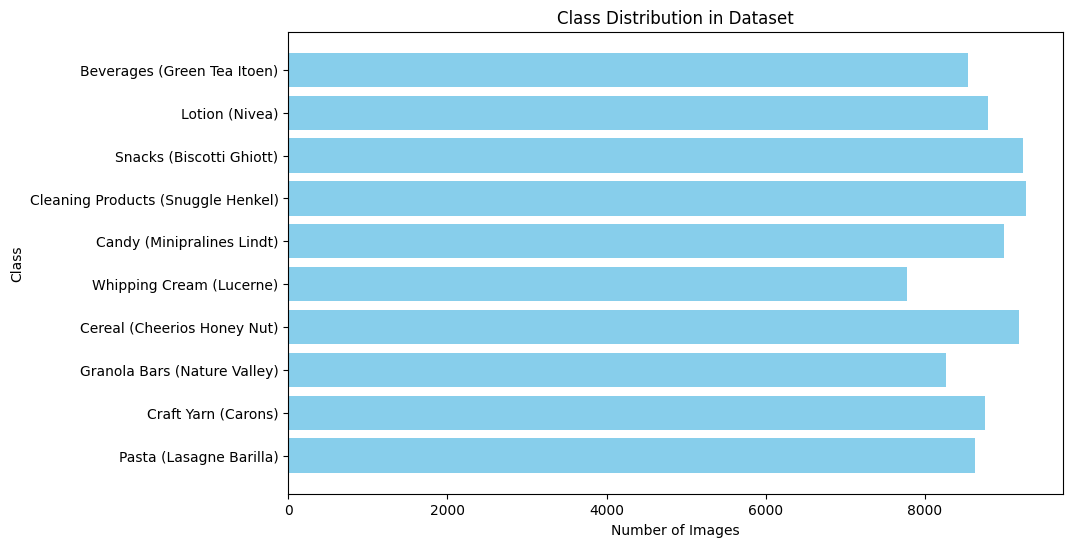

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


# Function to load and display random images from a folder
def load_random_image_from_folder(folder, num_images=3):
    files = os.listdir(folder)
    image_files = [f for f in files if f.endswith(('.jpg', '.jpeg', '.png'))]
    random_images = random.sample(image_files, num_images)

    images = []
    for img_file in random_images:
        img_path = os.path.join(folder, img_file)
        img = Image.open(img_path)
        images.append((img, img_file))

    return images

# Function to get class distribution from annotations
def get_class_distribution(annotations_folder, image_files):
    class_counts = {}

    for img_file in image_files:
        annotation_file = img_file.replace(".jpg", ".txt").replace(".jpeg", ".txt").replace(".png", ".txt")
        annotation_path = os.path.join(annotations_folder, annotation_file)

        if os.path.exists(annotation_path):
            with open(annotation_path, "r") as f:
                for line in f:
                    class_id = int(line.strip().split()[0])  # Assuming class_id is the first element in each line
                    if class_id in class_counts:
                        class_counts[class_id] += 1
                    else:
                        class_counts[class_id] = 1

    return class_counts

# Function to display a bar chart of class distribution
def plot_class_distribution(class_counts, class_names):
    # Convert class_ids to class names
    class_names_dict = {i: name for i, name in enumerate(class_names)}

    class_labels = [class_names_dict.get(class_id, f"Unknown {class_id}") for class_id in class_counts.keys()]
    class_values = list(class_counts.values())

    plt.figure(figsize=(10, 6))
    plt.barh(class_labels, class_values, color='skyblue')
    plt.xlabel("Number of Images")
    plt.ylabel("Class")
    plt.title("Class Distribution in Dataset")
    plt.show()

# Assuming you have class names for your dataset
class_names = [
    "Candy (Minipralines Lindt)",
    "Cereal (Cheerios Honey Nut)",
    "Cleaning Products (Snuggle Henkel)",
    "Craft Yarn (Carons)",
    "Beverages (Green Tea Itoen)",
    "Whipping Cream (Lucerne)",
    "Lotion (Nivea)",
    "Pasta (Lasagne Barilla)",
    "Snacks (Biscotti Ghiott)",
    "Granola Bars (Nature Valley)"
]
# Replace with actual class names

# Get class distribution for the train dataset
train_files = os.listdir(train_data)
train_image_files = [f for f in train_files if f.endswith(('.jpg', '.jpeg', '.png'))]
train_annotations_folder = os.path.join(dataset_path, "train/labels")  # Assuming labels are in train/labels

train_class_counts = get_class_distribution(train_annotations_folder, train_image_files)

# Plot the class distribution for the training dataset
plot_class_distribution(train_class_counts, class_names)

# You can repeat this for validation and test datasets if needed:
# val_class_counts = get_class_distribution(val_annotations_folder, val_image_files)
# plot_class_distribution(val_class_counts, class_names)


In [ ]:
model = YOLO('yolov8n.pt')

100%|██████████| 6.25M/6.25M [00:00<00:00, 281MB/s]


In [ ]:
results = model.train(
    data=os.path.join(dataset_path, 'data.yaml'),  # Path to the dataset's config file
    epochs=5,  # Adjust the number of epochs
    batch=16,  # Adjust batch size based on your GPU
    imgsz=640,  # Image size (YOLO default is 640x640)
    val=True,  # Perform validation after every epoch
    name='custom_yolov8',  # Name for the experiment/run
    save=True,  # Ensure model checkpoints are saved
    save_period=5,  # Save the model every 5 epochs
    cache=True  # Cache images for faster training
)

New https://pypi.org/project/ultralytics/8.3.40 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/datasets/GlassFoodBackgroundAllBalanced-3/data.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=5, cache=True, device=None, workers=8, project=None, name=custom_yolov8, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_mask

100%|██████████| 755k/755k [00:00<00:00, 84.7MB/s]


Overriding model.yaml nc=80 with nc=25

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytic

train: Scanning /content/datasets/GlassFoodBackgroundAllBalanced-3/train/labels... 10436 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10436/10436 [00:06<00:00, 1666.32it/s]


train: New cache created: /content/datasets/GlassFoodBackgroundAllBalanced-3/train/labels.cache
train: 13.4GB RAM required to cache images with 50% safety margin but only 10.1/12.7GB available, not caching images ⚠️
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

                   all       8464      18775       0.46      0.505      0.509      0.486

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        5/5      2.33G     0.3602     0.9984     0.8377         17        640: 100%|██████████| 653/653 [03:25<00:00,  3.18it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 265/265 [01:03<00:00,  4.16it/s]


                   all       8464      18775      0.498      0.535      0.534       0.51

5 epochs completed in 0.383 hours.
Optimizer stripped from runs/detect/custom_yolov8/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/custom_yolov8/weights/best.pt, 6.2MB

Validating runs/detect/custom_yolov8/weights/best.pt...
Ultralytics YOLOv8.2.103 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 265/265 [01:10<00:00,  3.76it/s]


                   all       8464      18775      0.498      0.535      0.533       0.51
                 beans        750       1539          0          0          0          0
                  cake        759       1317          0          0          0          0
                 candy        759       1258          0          0          0          0
                cereal        765       1300          0          0          0          0
                 chips        750       1612          0          0          0          0
             chocolate        753       1613          0          0          0          0
                coffee        161        401      0.395      0.711      0.567      0.542
                  corn        329        924      0.676      0.884      0.777       0.75
                  fish        750       2299          0          0          0          0
                 flour        162        304      0.611      0.628      0.644      0.629
                 hone